In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier

In [171]:
df_raw = pd.read_csv('0b05b2dd-4772-4fd5-b98a-8de02d94cd75_Data.csv', sep = ',')
df = df_raw.drop(columns = ['Country Name', 'Series Code'])
df = df.dropna(axis = 0)

id_vars = ["Country Code", "Series Name"]
value_vars = [c for c in df.columns if "[" in c and "YR" in c] 

df_long = df.melt(
    id_vars = id_vars,          # stay as identifier columns
    value_vars = value_vars,    # all the year columns
    var_name = "Year_raw",      # column that will hold things like "2005 [YR2005]"
    value_name = "Value"        # numeric data from those cells
)

df_long['Year'] = df_long['Year_raw'].str[0:4].astype(int)
df_long = df_long.drop(columns = 'Year_raw')

df_pivot = df_long.pivot(index = ['Country Code', 'Year'], columns = 'Series Name', values = 'Value')

df_pivot.columns.name = None

df_pivot['year_mask'] = (df_pivot.index.get_level_values('Year') > 2018) & (df_pivot.index.get_level_values('Year') < 2024)
df = df_pivot[df_pivot['year_mask']]

df = df.replace('..', None)

developed_reference = [
    "AND",  # Andorra
    "AUS",  # Australia
    "AUT",  # Austria
    "BEL",  # Belgium
    "CAN",  # Canada
    "HRV",  # Croatia
    "CYP",  # Cyprus
    "CZE",  # Czech Republic / Czechia
    "DNK",  # Denmark
    "EST",  # Estonia
    "FIN",  # Finland
    "FRA",  # France
    "DEU",  # Germany
    "GRC",  # Greece
    #"HKG",  # Hong Kong SAR
    "ISL",  # Iceland
    "IRL",  # Ireland
    "ISR",  # Israel
    "ITA",  # Italy
    "JPN",  # Japan
    "KOR",  # Korea (Republic of)
    "LVA",  # Latvia
    "LTU",  # Lithuania
    "LUX",  # Luxembourg
    #"MAC",  # Macao SAR
    "MLT",  # Malta
    "NLD",  # Netherlands
    "NZL",  # New Zealand
    "NOR",  # Norway
    "PRT",  # Portugal
    #"PRI",  # Puerto Rico
    "SMR",  # San Marino
    "SGP",  # Singapore
    "SVK",  # Slovak Republic
    "SVN",  # Slovenia
    "ESP",  # Spain
    "SWE",  # Sweden
    "CHE",  # Switzerland
    "GBR",  # United Kingdom
    "USA",  # United States
]

col_map = {
    "Access to clean fuels and technologies for cooking (% of population)": "clean_cooking",
    "Access to electricity (% of population)": "elec_total",
    "Access to electricity, rural (% of rural population)": "elec_rural",
    "Access to electricity, urban (% of urban population)": "elec_urban",
    "Current health expenditure (% of GDP)": "health_exp_gdp",
    "Current health expenditure per capita (current US$)": "health_exp_pc",
    "GDP per capita (current US$)": "gdp_pc",
    "GNI per capita, Atlas method (current US$)": "gni_pc_atlas",
    "Individuals using the Internet (% of population)": "internet_use",
    "Life expectancy at birth, total (years)": "life_exp",
    "People using at least basic drinking water services (% of population)": "basic_water",
    "People using at least basic drinking water services, rural (% of rural population)": "basic_water_rural",
    "People using at least basic drinking water services, urban (% of urban population)": "basic_water_urban",
    "Population density (people per sq. km of land area)": "pop_density",
    "Population, female": "pop_female",
    "Population, male": "pop_male",
    "Rural population (% of total population)": "rural_share",
    "School enrollment, primary (% gross)": "enroll_primary",
    "School enrollment, secondary (% gross)": "enroll_secondary",
    "Urban population (% of total population)": "urban_share",
    "Lifetime risk of maternal death (%)": "maternal_risk",
    "Mortality rate, infant, female (per 1,000 live births)": "infant_mort_f",
    "Mortality rate, infant, male (per 1,000 live births)": "infant_mort_m"
}

df.rename(col_map, axis = 1, inplace = True)


region_list = ["AFE", "AFW", "CSS", "EAS", "EAP", "EAR", "ECS", "ECA", "ECB",
    "EMU", "EUU", "FCS", "HIC", "HPC", "IBD", "IBT", "IDA", "IDX",
    "LAC", "LCN", "LCE", "LDC", "LIC", "LMC", "LMY", "MIC", "NOC",
    "OED", "OSS", "PSS", "PDI", "PRE", "SAS", "TSA", "SSA", "SSF",
    "SSX", "UMC", "WLD", "ARB", "MNA", "TMN", "MXX",
    "SAR", "MEA", "PST", "TEA", "LTE", "NAC", "IDB",
    "CEB", 'TEC', 'SST']

df = df[~df.index.get_level_values("Country Code").isin(region_list)]

flag = df.isna().sum()/df.shape[0] < 0.3
df = df.loc[:, flag]

df = df.map(lambda x: round(float(x), 2), na_action = "ignore")

df['usable_year'] = df.isna().mean(axis = 1)
df['flag'] = df['usable_year'] < 0.2

country_mask = df.groupby("Country Code")['flag'].mean() > 0.7
df["analisable"] = df.index.get_level_values("Country Code").map(country_mask)
df_good_prefillna = df[df['analisable']]
df_bad = df[~df['analisable']]

df_good_prefillna = df_good_prefillna.drop(columns = ['flag', 'analisable', 'year_mask', 'usable_year'])

df_good = df_good_prefillna.fillna(df_good_prefillna.groupby("Country Code").median())

small_na_cols = ['clean_cooking', 'elec_rural', 'internet_use', 'gni_pc_atlas', 'basic_water']
df_good[small_na_cols] = df_good[small_na_cols].fillna(df_good[small_na_cols].median())

big_na_cols = ['basic_water_rural', 'basic_water_urban', 'enroll_primary'] 
df_good = df_good.drop(columns = big_na_cols)

df_good = df_good.dropna()

loggable = ['health_exp_pc', 'gdp_pc', 'gni_pc_atlas', 'maternal_risk', 'pop_density', 'pop_female', 
'pop_male']
df_good[loggable] = np.log1p(df_good[loggable])

df_good = df_good.groupby('Country Code').mean()
country_index = df_good.index

df_good = df_good.reset_index().drop(columns = 'Country Code')

scaler = StandardScaler()
data = scaler.fit_transform(df_good)

In [172]:
for k in np.arange(2,5):

    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 'auto').fit(data)
    df_good['KMCluster' + str(k)] = kmeans.labels_

    sil = silhouette_score(data, kmeans.labels_)
    CHscore = calinski_harabasz_score(data, kmeans.labels_)
    print(sil, CHscore)

0.44109631044829495 161.18974194942035
0.2560599972516708 121.90548321834605
0.24789127556812196 95.91309434780689


In [173]:
df_good = df_good.set_index(country_index)
df_good

,clean_cooking,elec_total,elec_rural,elec_urban,health_exp_gdp,health_exp_pc,gdp_pc,gni_pc_atlas,internet_use,life_exp,...,infant_mort_m,basic_water,pop_density,pop_female,pop_male,rural_share,urban_share,KMCluster2,KMCluster3,KMCluster4
Country Code,,,,,,,,,,,,,,,,,,,,,
AFG,35.90,92.74,90.88,98.08,18.696,4.385667,6.047161,6.045480,17.212,63.292,...,57.18,74.484,4.126821,16.795913,16.815066,74.678,25.322,1,1,1
AGO,49.72,48.08,100.00,74.98,2.956,4.255128,7.845572,7.733523,38.996,63.600,...,45.52,65.704,3.356381,16.674596,16.652753,31.746,68.254,1,1,1
ALB,84.30,100.00,100.00,100.00,7.016,6.014435,8.888600,8.849816,77.172,78.500,...,8.98,95.022,4.520381,14.045076,14.023915,42.504,57.496,0,0,0
AND,100.00,100.00,100.00,100.00,7.982,8.110859,10.644150,10.731675,93.554,82.782,...,3.00,100.000,5.124599,10.557347,10.598705,11.328,88.672,0,2,2
ARE,100.00,100.00,100.00,100.00,5.038,7.684493,10.725315,10.730755,99.830,81.404,...,4.90,100.000,4.933111,15.068027,15.654173,14.646,85.354,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VUT,18.26,67.00,57.44,94.36,4.091,4.864047,8.083024,8.206819,43.196,70.780,...,15.56,86.924,3.261591,11.926637,11.948778,77.462,22.538,1,0,0
WSM,37.66,99.16,98.96,99.98,6.239,5.529245,8.361068,8.353670,54.196,71.070,...,14.94,97.254,4.354001,11.571111,11.585081,82.194,17.806,0,0,3
ZAF,88.62,87.70,91.34,88.00,8.684,6.313490,8.746300,8.758498,73.580,64.964,...,26.80,90.918,3.944357,17.268854,17.211005,36.528,63.472,0,0,0


In [174]:
df_good = df_good.drop(columns = ['KMCluster2', 'KMCluster3', 'KMCluster4'])

In [175]:
hac = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward').fit(data)

In [176]:
gmm = GaussianMixture(2, random_state = 42)
gmm.fit(data)
gmm_labels = gmm.predict(data)

In [177]:
pca = PCA(n_components=2)
pca.fit(data)
pcas = pd.DataFrame(pca.transform(data), columns = ['pca1', 'pca2'])
pcas = pcas.set_index(country_index)
pcas['gmm2'] = gmm_labels
pcas['hac_ward'] = hac.labels_
pcas['diff'] = abs(pcas['hac_ward'] - pcas['gmm2'])

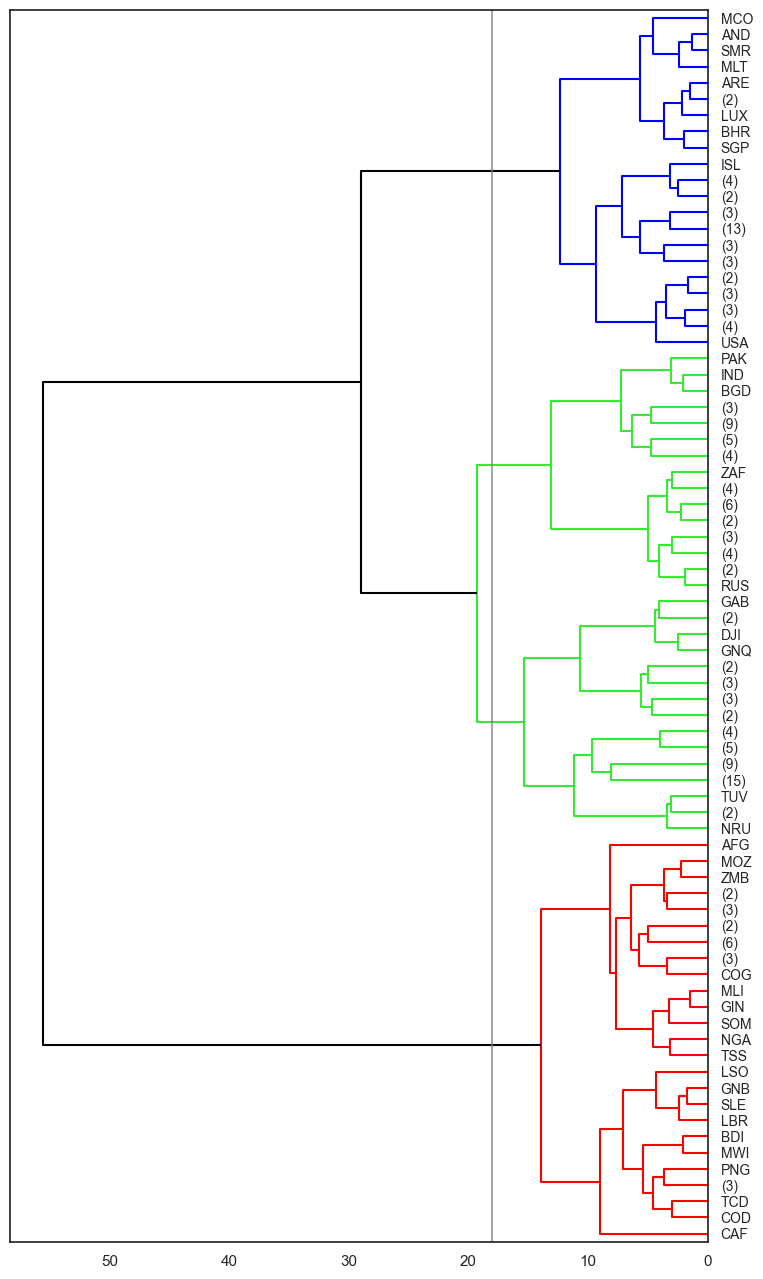

In [178]:
plt.figure(figsize = (9,16))
Z = sch.linkage(data, method = 'ward', optimal_ordering = True)
sch.set_link_color_palette(['red', '#34eb34', 'blue', '#ae34eb'])

# Draw a dendrogram
sch.dendrogram(Z, p = 6, truncate_mode = 'level', leaf_font_size=10, 
                labels=list(df_good.index), orientation = 'left',
               color_threshold=25, above_threshold_color='black')

plt.axvline(x = 18, color = 'grey', alpha = 0.7)
plt.show()

In [179]:
pcas['hac_ward_4'] = sch.fcluster(Z, t = 18, criterion = 'distance')
pcas['hac_ward_4_2'] = pcas['hac_ward_4'] // 4

In [180]:
gmm4 = GaussianMixture(4, random_state = 42)
gmm4.fit(data)
gmm4_labels = gmm4.predict(data)
pcas['gmm4'] = gmm4_labels
pcas

,pca1,pca2,gmm2,hac_ward,diff,hac_ward_4,hac_ward_4_2,gmm4
Country Code,,,,,,,,
AFG,-4.474296,-0.067918,1,1,0,1,0,1
AGO,-3.450505,1.143705,1,1,0,1,0,1
ALB,1.531309,-0.458581,0,0,0,2,0,2
AND,4.078739,-2.303740,0,0,0,4,1,2
ARE,3.577636,0.673111,0,0,0,4,1,2
...,...,...,...,...,...,...,...,...
VUT,-2.093532,-2.099247,1,0,1,2,0,1
WSM,-0.576911,-2.517858,0,0,0,2,0,3
ZAF,-0.115463,1.227088,1,0,1,3,0,0


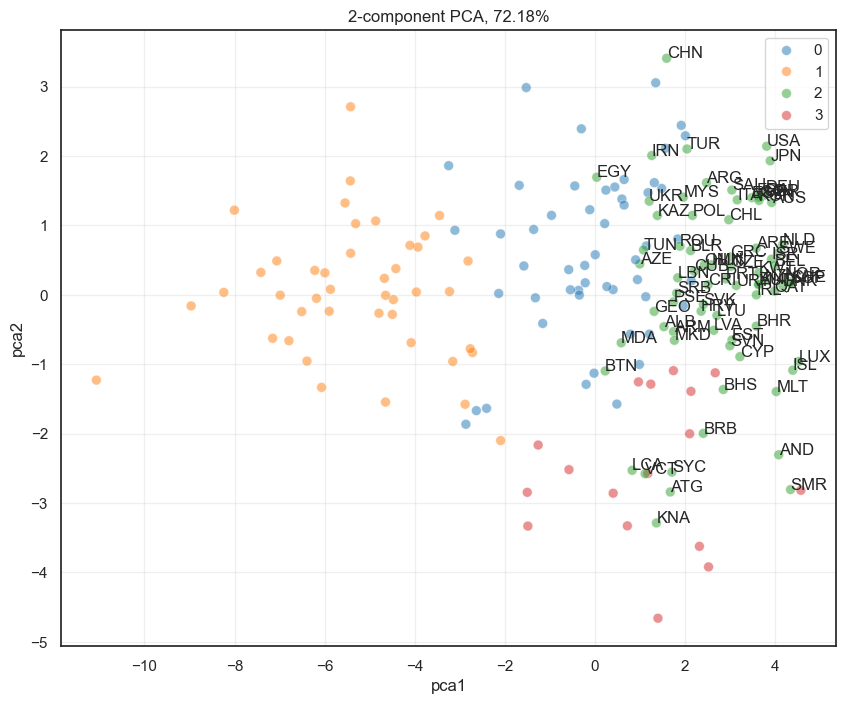

In [181]:
plt.figure(figsize = (10, 8))
sns.scatterplot(pcas, x = 'pca1', y = 'pca2', hue = 'gmm4',
marker = 'o', palette = 'tab10', s = 50, alpha = 0.5)
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title(f'{pca.n_components_}-component PCA, {sum(pca.explained_variance_ratio_)*100:.2f}%')
plt.grid(alpha = 0.3)
plt.legend()

for country in pcas[pcas['gmm4'] == 2].index:
    
    plt.annotate(country, xy = [pcas.loc[country]['pca1'], pcas.loc[country]['pca2']])

plt.show()

In [182]:
pcas.loc[developed_reference, 'reference'] = 1
pcas['reference'] = pcas['reference'].fillna(0)

In [183]:
pd.crosstab(pcas['reference'], pcas['gmm4'])

gmm4,0,1,2,3
reference,,,,
0.0,52,43,40,17
1.0,0,0,37,0


In [184]:
pd.crosstab(pcas['reference'], pcas['hac_ward_4_2'])

hac_ward_4_2,0,1
reference,,
0.0,137,15
1.0,0,37


In [185]:
y = pcas['hac_ward_4_2']
scores = []
RF = []

RF.append(RandomForestClassifier(
    n_estimators = 100,
    min_samples_leaf = 2,
    max_depth = 6))

RF.append(RandomForestClassifier(
    n_estimators = 400,
    min_samples_leaf = 2,
    max_depth = 6))

RF.append(RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 6))
    
RF.append(RandomForestClassifier(
    n_estimators = 50,
    min_samples_leaf = 5,
    max_depth = 6))

for model in RF:
    
    scores.append(cross_validate(model, data, y, cv = 5, scoring = ['precision', 'recall', 'accuracy']))
    

scores


[{'fit_time': array([0.08438516, 0.08329892, 0.0792973 , 0.07845211, 0.08359528]),
  'score_time': array([0.01022124, 0.01155186, 0.00911999, 0.01007199, 0.01002169]),
  'test_precision': array([0.66666667, 1.        , 1.        , 0.81818182, 1.        ]),
  'test_recall': array([0.8       , 0.9       , 0.90909091, 0.81818182, 1.        ]),
  'test_accuracy': array([0.84210526, 0.97368421, 0.97368421, 0.89473684, 1.        ])},
 {'fit_time': array([0.3225162 , 0.33375025, 0.38893223, 0.32754159, 0.37883949]),
  'score_time': array([0.02366138, 0.02738833, 0.02734947, 0.0247767 , 0.02341294]),
  'test_precision': array([0.66666667, 1.        , 1.        , 0.75      , 1.        ]),
  'test_recall': array([0.8       , 0.9       , 0.90909091, 0.81818182, 1.        ]),
  'test_accuracy': array([0.84210526, 0.97368421, 0.97368421, 0.86842105, 1.        ])},
 {'fit_time': array([0.16045642, 0.16814327, 0.16749287, 0.17874122, 0.15976572]),
  'score_time': array([0.01503086, 0.01443338, 0.0142

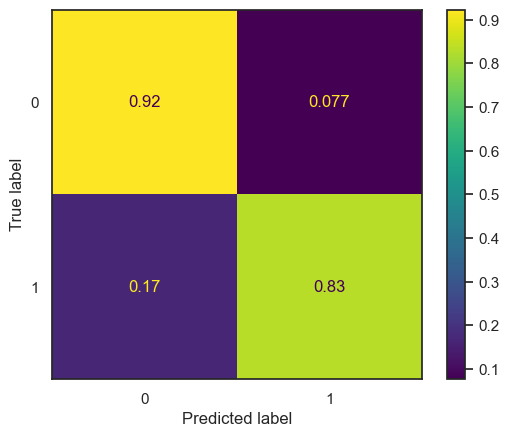

In [186]:
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size = 0.2, random_state = 42)

rf = RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 6, 
    random_state = 42)

rf = rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred, normalize = 'true')

ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot()

In [187]:
print(classification_report(y_test, y_pred, target_names=['0','1']))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       0.83      0.83      0.83        12

    accuracy                           0.89        38
   macro avg       0.88      0.88      0.88        38
weighted avg       0.89      0.89      0.89        38



In [188]:
df_good.loc['rf_importance'] = rf.feature_importances_
df_good

,clean_cooking,elec_total,elec_rural,elec_urban,health_exp_gdp,health_exp_pc,gdp_pc,gni_pc_atlas,internet_use,life_exp,maternal_risk,infant_mort_f,infant_mort_m,basic_water,pop_density,pop_female,pop_male,rural_share,urban_share
Country Code,,,,,,,,,,,,,,,,,,,
AFG,35.900000,92.740000,90.880000,98.080000,18.69600,4.385667,6.047161,6.045480,17.212000,63.292000,1.359750,49.900000,57.180000,74.484000,4.126821,16.795913,16.815066,74.67800,25.322000
AGO,49.720000,48.080000,100.000000,74.980000,2.95600,4.255128,7.845572,7.733523,38.996000,63.600000,0.710457,36.160000,45.520000,65.704000,3.356381,16.674596,16.652753,31.74600,68.254000
ALB,84.300000,100.000000,100.000000,100.000000,7.01600,6.014435,8.888600,8.849816,77.172000,78.500000,0.011921,7.340000,8.980000,95.022000,4.520381,14.045076,14.023915,42.50400,57.496000
AND,100.000000,100.000000,100.000000,100.000000,7.98200,8.110859,10.644150,10.731675,93.554000,82.782000,0.017775,2.340000,3.000000,100.000000,5.124599,10.557347,10.598705,11.32800,88.672000
ARE,100.000000,100.000000,100.000000,100.000000,5.03800,7.684493,10.725315,10.730755,99.830000,81.404000,0.003980,4.020000,4.900000,100.000000,4.933111,15.068027,15.654173,14.64600,85.354000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WSM,37.660000,99.160000,98.960000,99.980000,6.23900,5.529245,8.361068,8.353670,54.196000,71.070000,0.341993,12.180000,14.940000,97.254000,4.354001,11.571111,11.585081,82.19400,17.806000
ZAF,88.620000,87.700000,91.340000,88.000000,8.68400,6.313490,8.746300,8.758498,73.580000,64.964000,0.250395,22.780000,26.800000,90.918000,3.944357,17.268854,17.211005,36.52800,63.472000
ZMB,10.300000,46.640000,14.960000,84.940000,6.28700,4.315126,7.099739,7.082730,24.740000,64.052000,0.369776,30.060000,36.400000,70.220000,3.309076,16.107771,16.087426,55.75600,44.244000


In [189]:
df_good.loc['rf_importance'].sort_values(ascending = False)

gdp_pc            0.194287
health_exp_pc     0.154193
life_exp          0.153269
gni_pc_atlas      0.117676
internet_use      0.095503
clean_cooking     0.069862
infant_mort_m     0.045127
maternal_risk     0.044645
infant_mort_f     0.034203
rural_share       0.024570
basic_water       0.024432
urban_share       0.013178
health_exp_gdp    0.007220
pop_female        0.006091
pop_density       0.005954
elec_total        0.003367
pop_male          0.002808
elec_rural        0.002802
elec_urban        0.000811
Name: rf_importance, dtype: float64

The most important are gdp per capita, life expectancy, health expedinture per capita, gni per capita, infant mortality, access to basic water

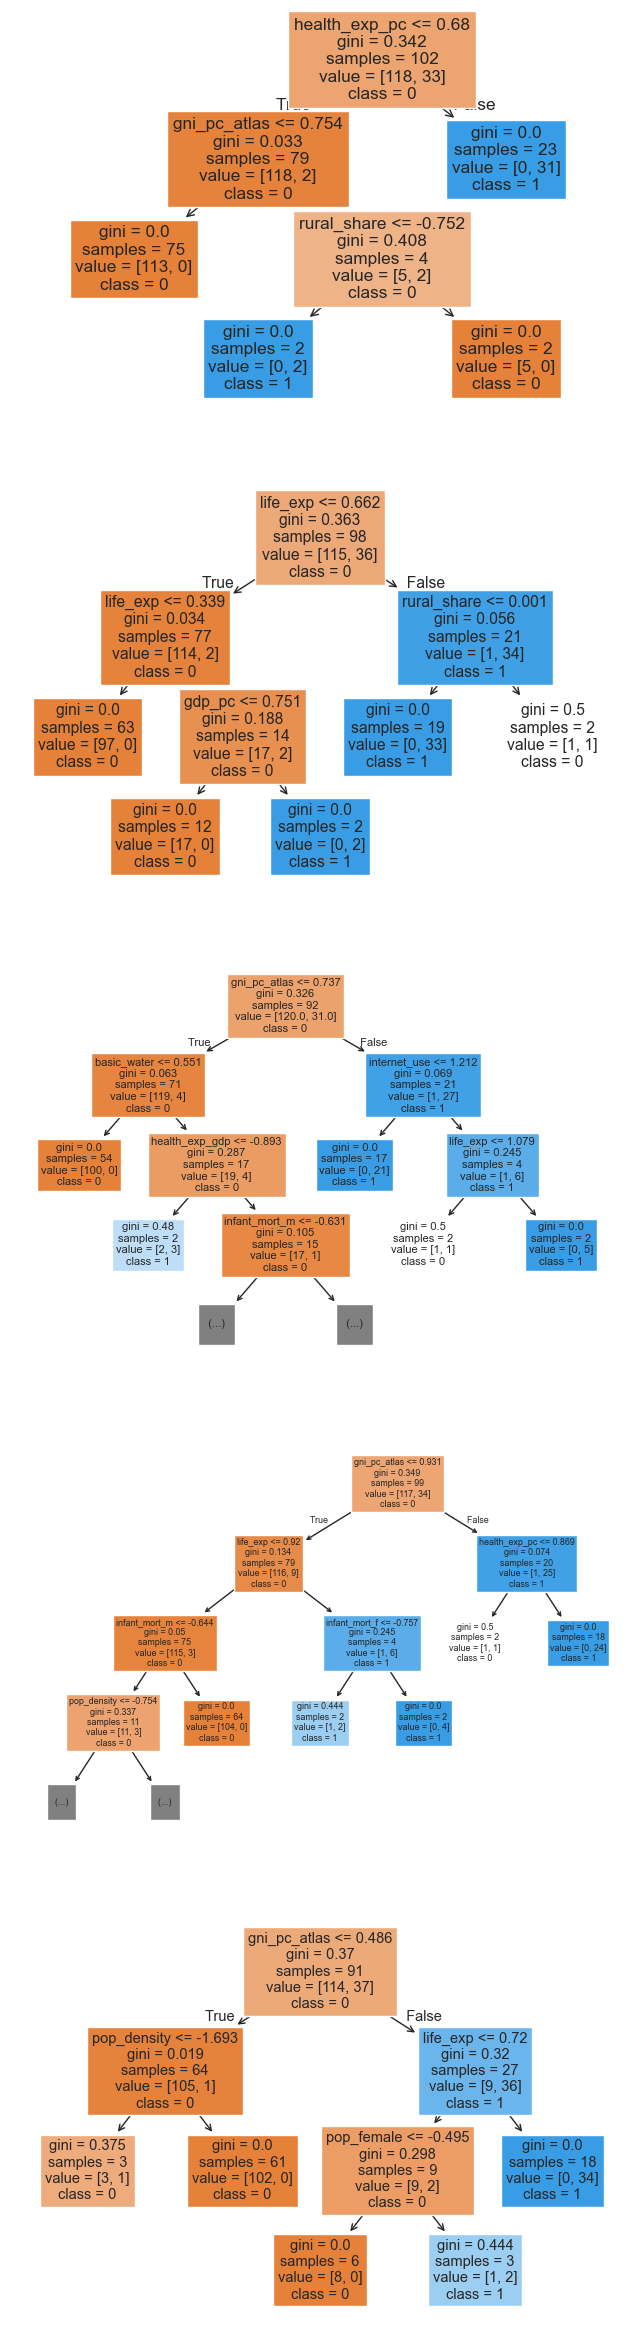

In [190]:
fig, axs = plt.subplots(5, 1, figsize = (8, 30))
for i in np.arange(1,6):
    plt.subplot(5, 1 ,i)
    plot_tree(rf.estimators_[i - 1], feature_names = df_good.columns, class_names = ['0', '1'], max_depth = 3, filled = True)
plt.show()

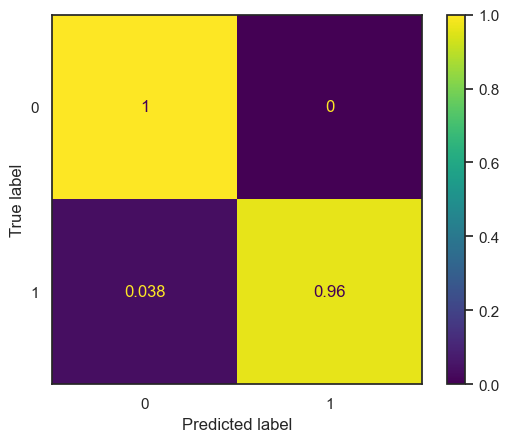

In [191]:
rf = RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 6, 
    random_state = 42)

rf = rf.fit(data, y)

y_pred = rf.predict(data)
pcas['rf'] = y_pred
cm = confusion_matrix(y, y_pred, normalize = 'true')

ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot()

In [192]:
print(classification_report(y, y_pred, target_names=['0','1']))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       137
           1       1.00      0.96      0.98        52

    accuracy                           0.99       189
   macro avg       0.99      0.98      0.99       189
weighted avg       0.99      0.99      0.99       189



In [193]:
df_good.loc['rf_importance'] = rf.feature_importances_
df_good.loc['rf_importance'].sort_values(ascending = False)

gdp_pc            0.200700
health_exp_pc     0.163502
life_exp          0.136583
gni_pc_atlas      0.097007
infant_mort_m     0.084627
infant_mort_f     0.055913
clean_cooking     0.055509
internet_use      0.052088
maternal_risk     0.041554
basic_water       0.028338
rural_share       0.016275
urban_share       0.014716
pop_female        0.011046
elec_rural        0.009464
health_exp_gdp    0.009261
elec_total        0.008489
pop_density       0.007275
pop_male          0.007171
elec_urban        0.000482
Name: rf_importance, dtype: float64

In [194]:
df_reduced = df_good.loc[:, df_good.loc['rf_importance'] > 0.048]
df_reduced['infant_mort'] = (df_reduced['infant_mort_f'] + df_reduced['infant_mort_m'])/2
df_reduced = df_reduced.drop(columns = ['infant_mort_f', 'infant_mort_m'])

df_reduced = df_reduced.loc[:'ZWE']
df_reduced = df_reduced.reset_index().drop(columns = 'Country Code')

C:\Users\4infi\AppData\Local\Temp\ipykernel_2200\1713586839.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced['infant_mort'] = (df_reduced['infant_mort_f'] + df_reduced['infant_mort_m'])/2


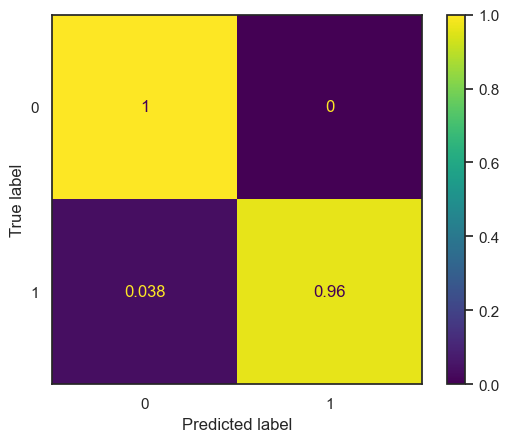

In [195]:
data_reduced = scaler.fit_transform(df_reduced)

rf_red = RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 6, 
    random_state = 42)

rf_red = rf_red.fit(data_reduced, y)

y_pred = rf_red.predict(data_reduced)

cm = confusion_matrix(y, y_pred, normalize = 'true')

ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot()

pcas['rf_red'] = y_pred

In [196]:
df_reduced.loc['rf_importance'] = rf_red.feature_importances_
df_reduced.loc['rf_importance'].sort_values(ascending = False)

health_exp_pc    0.231954
gdp_pc           0.208679
life_exp         0.197279
gni_pc_atlas     0.119693
infant_mort      0.115241
internet_use     0.063993
clean_cooking    0.063161
Name: rf_importance, dtype: float64

In [197]:
print(classification_report(y, y_pred, target_names=['0','1']))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       137
           1       1.00      0.96      0.98        52

    accuracy                           0.99       189
   macro avg       0.99      0.98      0.99       189
weighted avg       0.99      0.99      0.99       189



More countries is impossible

In [198]:
pcas['rf_diff'] = abs(pcas['rf'] - pcas['rf_red'])


In [199]:
dtc = DecisionTreeClassifier(
    min_samples_leaf = 2,
    max_depth = 6, 
    random_state = 42)
dtc = dtc.fit(data_reduced, pcas['rf'])



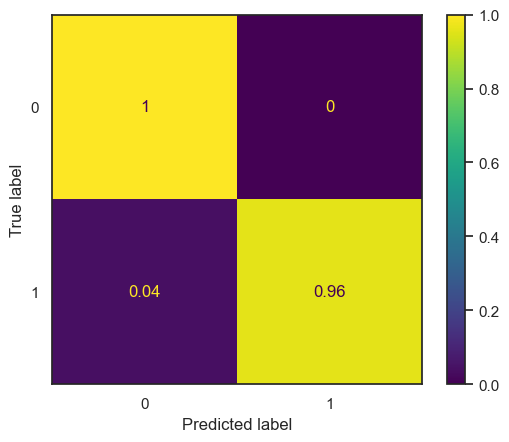

In [200]:
cm = confusion_matrix(pcas['rf'], dtc.predict(data_reduced), normalize = 'true')

ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot()

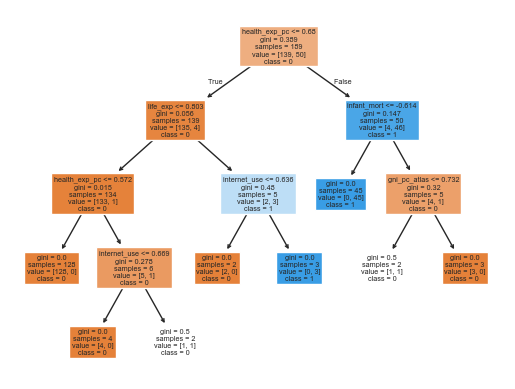

In [201]:
figsize = (16,9)
plot_tree(dtc, max_depth = 8, feature_names = df_reduced.columns, class_names = ['0','1'], filled = True)
plt.show()

In [202]:
pcas


,pca1,pca2,gmm2,hac_ward,diff,hac_ward_4,hac_ward_4_2,gmm4,reference,rf,rf_red,rf_diff
Country Code,,,,,,,,,,,,
AFG,-4.474296,-0.067918,1,1,0,1,0,1,0.0,0,0,0
AGO,-3.450505,1.143705,1,1,0,1,0,1,0.0,0,0,0
ALB,1.531309,-0.458581,0,0,0,2,0,2,0.0,0,0,0
AND,4.078739,-2.303740,0,0,0,4,1,2,1.0,1,1,0
ARE,3.577636,0.673111,0,0,0,4,1,2,0.0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
VUT,-2.093532,-2.099247,1,0,1,2,0,1,0.0,0,0,0
WSM,-0.576911,-2.517858,0,0,0,2,0,3,0.0,0,0,0
ZAF,-0.115463,1.227088,1,0,1,3,0,0,0.0,0,0,0


In [203]:
df_pivot.rename(col_map, axis = 1, inplace = True)

col20 = ['gdp_pc', 'health_exp_gdp', 'elec_total', 'infant_mort_f', 'infant_mort_m',
'pop_male', 'pop_female', 'basic_water','enroll_primary']

df_pivot = df_pivot[col20]

df_pivot = df_pivot.replace('..', None)
df_pivot = df_pivot[~df_pivot.index.get_level_values("Country Code").isin(region_list)]
df_pivot = df_pivot.map(lambda x: round(float(x), 2), na_action = "ignore")

df_pivot['usable_year'] = df_pivot.isna().mean(axis = 1)
df_pivot['flag'] = df_pivot['usable_year'] <= 0.2
country_mask = df_pivot.groupby("Country Code")['flag'].mean() > 0.7
df_pivot["analisable"] = df_pivot.index.get_level_values("Country Code").map(country_mask)

df20_good_prefillna = df_pivot[df_pivot['analisable']]
df20_bad = df_pivot[~df_pivot['analisable']]

df20_good_prefillna = df20_good_prefillna.drop(columns = ['flag', 'analisable', 'usable_year'])

In [204]:
df20_good_prefillna.isna().sum()

gdp_pc             13
health_exp_gdp    371
elec_total        188
infant_mort_f     186
infant_mort_m     186
pop_male            0
pop_female          0
basic_water        38
enroll_primary    636
dtype: int64

In [205]:
df20 = df20_good_prefillna.copy()
df20['infant_mort'] = (df20['infant_mort_f'] + df20['infant_mort_m'])/2
df20['pop'] = (df20['pop_female'] + df20['pop_male'])/2
df20.drop(columns = ['infant_mort_f','infant_mort_m','pop_female', 'pop_male'], inplace = True)
ffill_cols = ['elec_total', 'basic_water', 'enroll_primary', 'infant_mort']
df20[ffill_cols] = df20.groupby('Country Code')[ffill_cols].fillna(method = 'ffill')
df20[['basic_water', 'enroll_primary']] = df20.groupby('Country Code')[['basic_water', 'enroll_primary']].fillna(method = 'bfill')
df20['elec_total'].fillna(0, inplace = True)

df20['gdp_growth'] = (df20["gdp_pc"]/
    df20.groupby("Country Code")["gdp_pc"].shift(1))

df20['log_gdp_growth'] = np.log(df20['gdp_growth'])
meanlog_gdp_growth = df20.groupby('Country Code')['log_gdp_growth'].transform('mean')
df20['log_gdp_growth'] = df20['log_gdp_growth'].fillna(meanlog_gdp_growth)
df20['gdp_growth'] = df20['gdp_growth'].fillna(np.exp(df20['log_gdp_growth']))

NA = df20['gdp_pc'].isna().sum() + 1

while NA - df20['gdp_pc'].isna().sum() > 0:
    NA = df20['gdp_pc'].isna().sum()
    df20['gdp_pc'] = df20['gdp_pc'].fillna(df20['gdp_pc'].shift(1) * df20['gdp_growth'])

NA = df20['health_exp_gdp'].isna().sum() + 1
    
while NA - df20['health_exp_gdp'].isna().sum() > 0:

    NA = df20['health_exp_gdp'].isna().sum()
    
    df20['health_exp_gdp'] = df20['health_exp_gdp'].fillna(
        df20.groupby("Country Code")["health_exp_gdp"].shift(1) * df20.groupby("Country Code")["gdp_pc"].shift(1)/
        df20['gdp_pc']
    )

df20['health_exp_gdp'] = df20.groupby("Country Code")["health_exp_gdp"].bfill()

C:\Users\4infi\AppData\Local\Temp\ipykernel_2200\2973891650.py:6: FutureWarning: DataFrameGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use DataFrame.fillna instead
  df20[ffill_cols] = df20.groupby('Country Code')[ffill_cols].fillna(method = 'ffill')
C:\Users\4infi\AppData\Local\Temp\ipykernel_2200\2973891650.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df20[ffill_cols] = df20.groupby('Country Code')[ffill_cols].fillna(method = 'ffill')
C:\Users\4infi\AppData\Local\Temp\ipykernel_2200\2973891650.py:7: FutureWarning: DataFrameGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use DataFrame.fillna instead
  df20[['basic_water

In [206]:
df20['gdp'] = df20['gdp_pc'] * df20['pop']/1e+6

total_economy = pd.DataFrame(df20.groupby('Year')['gdp'].sum())
total_economy['growth'] = total_economy['gdp']/total_economy['gdp'].shift(1)
total_economy['growth'] = total_economy['growth'].fillna(total_economy['growth'].mean())

df20.loc[:, 'gdp_growth_vs_total'] = df20.loc[:, 'gdp_growth'] - total_economy['growth']

In [207]:
df20_total = pd.DataFrame(index = df20.groupby('Country Code').mean().index)

df20_start = df20[df20.index.get_level_values('Year') == 2005].reset_index('Year')
df20_end = df20[df20.index.get_level_values('Year') == 2024].reset_index('Year')

df20_total['hac_cluster'] = pcas['hac_ward_4']

df20_total['gdp'] = np.log(df20_end['gdp_pc'])
df20_total['log_gdp_growth'] = np.exp(df20.groupby('Country Code')['log_gdp_growth'].mean()) - 1
df20_total['max_gdp_growth'] = df20.groupby('Country Code')['gdp_growth_vs_total'].max()
df20_total['year_max_growth'] = df20.groupby('Country Code')['gdp_growth_vs_total'].idxmax().map(lambda x: x[1]) - 2005
df20_total['min_gdp_growth'] = df20.groupby('Country Code')['gdp_growth_vs_total'].min()
df20_total['year_min_growth'] = df20.groupby('Country Code')['gdp_growth_vs_total'].idxmin().map(lambda x: x[1]) - 2005

df20_total['avg_infant_mort'] = df20.groupby('Country Code')['infant_mort'].mean()
df20_total['start_infant_mort'] = df20_start['infant_mort']
df20_total['infant_mort'] = df20_end['infant_mort']
df20_total['peak_health_exp'] = df20.groupby('Country Code')['health_exp_gdp'].max()

df20_total['basic_water'] = df20_end['basic_water']
df20_total['elec'] = df20_end['elec_total']

df20_total['enroll_primary'] = df20_end['enroll_primary']
df20_total['enroll_primary_growth'] = (df20_total['enroll_primary'] / df20_start['enroll_primary']) ** (1/19)

df20_total['pop'] = np.log(df20_end['pop'])

df20_total['hac_cluster'] = df20_total['hac_cluster'].fillna(1)

for country in df20_total.index:
    df20_total.loc[country] = df20_total.loc[country].fillna(
        df20_total.groupby('hac_cluster').mean().loc[df20_total.loc[country, 'hac_cluster']])

df20_total

,hac_cluster,gdp,log_gdp_growth,max_gdp_growth,year_max_growth,min_gdp_growth,year_min_growth,avg_infant_mort,start_infant_mort,infant_mort,peak_health_exp,basic_water,elec,enroll_primary,enroll_primary_growth,pop
Country Code,,,,,,,,,,,,,,,,
AFG,1.0,6.052355,0.027439,0.240274,2,-0.445450,16,67.6550,93.55,50.25,23.090000,80.83,85.3,109.08,1.004850,16.875332
AGO,1.0,7.888286,0.011485,0.550091,17,-0.447764,11,57.7800,94.10,38.20,4.046927,67.96,51.1,86.74,0.989335,16.756941
ALB,2.0,9.339418,0.077775,0.208322,18,-0.122144,5,9.0925,13.50,8.25,7.500000,95.12,100.0,111.51,1.002165,13.988256
AND,4.0,10.805753,0.009975,0.057553,18,-0.134763,5,3.6075,5.35,2.50,8.790000,100.00,100.0,99.86,1.005451,10.620571
ARE,4.0,10.825234,0.013839,0.102423,17,-0.192145,4,5.9625,7.70,3.95,5.820000,100.00,100.0,108.04,1.001143,15.519022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VNM,3.0,8.458990,0.104745,0.265863,5,-0.095243,16,15.6950,18.00,13.95,5.070000,98.76,99.8,106.33,1.000713,17.737362
VUT,2.0,8.134693,0.032021,0.036536,17,-0.122288,16,16.2175,19.80,14.15,4.550000,87.12,61.6,112.49,0.997741,12.006942
WSM,2.0,8.592835,0.040207,0.120893,18,-0.162425,16,14.5850,15.00,12.70,6.810000,99.44,100.0,101.04,0.999317,11.599190


In [208]:
data20 = scaler.fit_transform(df20_total.reset_index().drop(columns = ['hac_cluster','Country Code']))


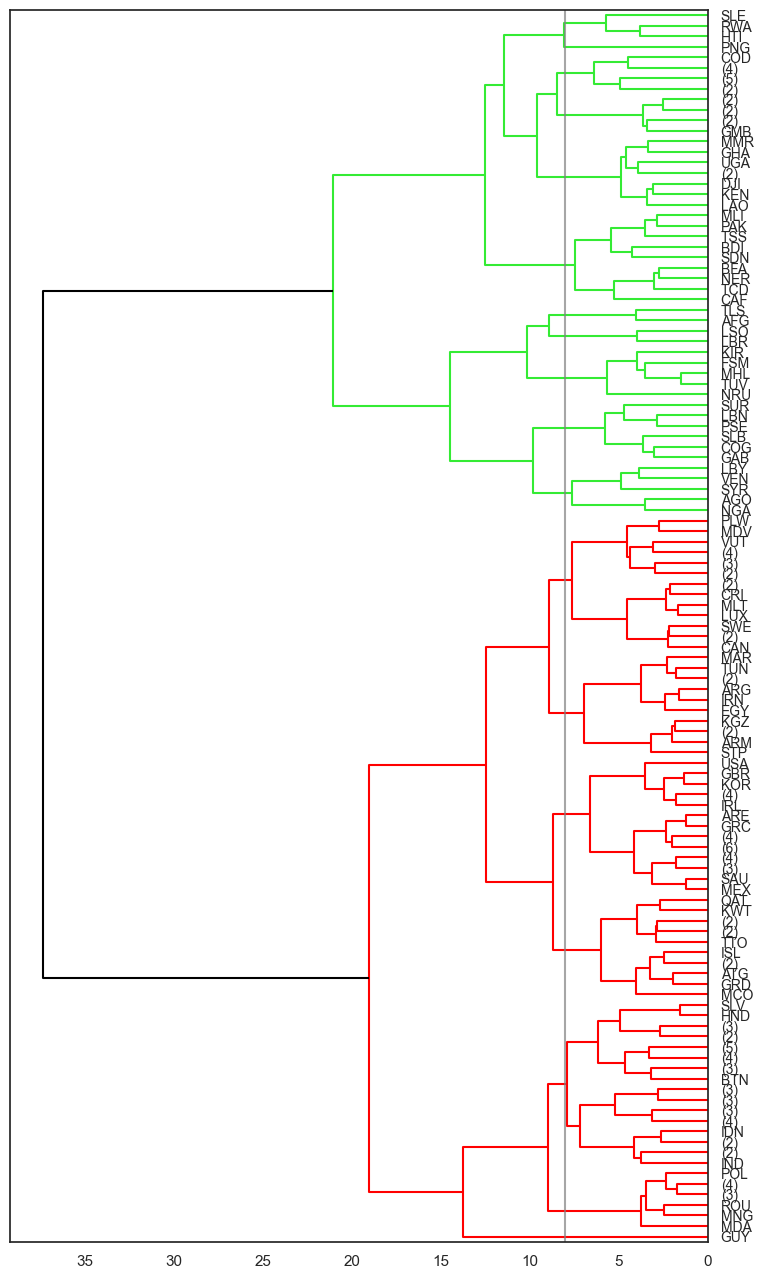

In [209]:
plt.figure(figsize = (9,16))
Z = sch.linkage(data20, method = 'ward', optimal_ordering = True)
sch.set_link_color_palette(['red', '#34eb34', 'blue', '#ae34eb'])

# Draw a dendrogram
sch.dendrogram(Z, p = 7, truncate_mode = 'level', leaf_font_size=10, 
                labels=list(df20_total.index), orientation = 'left',
               color_threshold=25, above_threshold_color='black')

plt.axvline(x = 8, color = 'grey', alpha = 0.7)
plt.show()

In [210]:
result20 = pd.DataFrame(index = df20_total.index)
result20['hac18'] = sch.fcluster(Z, t = 8, criterion = 'distance')
result20

,hac18
Country Code,
AFG,12
AGO,8
ALB,6
AND,4
ARE,5
...,...
VNM,2
VUT,7
WSM,7


In [211]:
hac18_cross = pd.crosstab(pcas['hac_ward_4'],result20['hac18'])
hac18_cross

hac18,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
hac_ward_4,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,2,1,0,2,1,8,5,1,12,3,1
2,4,9,1,4,1,4,11,0,5,5,0,1,0,1,4,0,0,0
3,3,26,0,1,1,7,1,2,0,0,0,0,1,2,2,0,0,0
4,4,4,0,7,27,1,9,0,0,0,0,0,0,0,0,0,0,0


In [212]:
for i in hac18_cross.columns:

        for country in result20[result20['hac18'] == i].index:
            
            if hac18_cross.loc[4, i] == 0:
        
                result20.loc[country, 'hac18_3'] = 0

            elif hac18_cross.loc[4, i] > 0.85 * hac18_cross[i].sum():

                result20.loc[country, 'hac18_3'] = 2

            else: 
                result20.loc[country, 'hac18_3'] = 1


In [213]:
y = result20['hac18_3']
data20_forest = scaler.fit_transform(df20_total.reset_index().drop(columns = 'Country Code'))
scores = []
RF20 = []

RF20.append(RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 6))

RF20.append(RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 4,
    max_depth = 6))

RF20.append(RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 6,
    max_depth = 6))
    
RF20.append(RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 8))

RF20.append(RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 10))

for model in RF20:
    
    scores.append(cross_validate(model, data20_forest, y, cv = 5, scoring = ['precision', 'recall', 'accuracy']))
    
scores

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\4infi\AppData\Local\Programs\Python\Pytho

[{'fit_time': array([0.17253399, 0.17209125, 0.17537069, 0.17377853, 0.19587588]),
  'score_time': array([0.01410437, 0.01318717, 0.01418018, 0.01300287, 0.01463938]),
  'test_precision': array([nan, nan, nan, nan, nan]),
  'test_recall': array([nan, nan, nan, nan, nan]),
  'test_accuracy': array([0.92105263, 0.91891892, 0.89189189, 0.83783784, 0.78378378])},
 {'fit_time': array([0.18379712, 0.22046232, 0.17126489, 0.17218113, 0.17044735]),
  'score_time': array([0.01426482, 0.01411295, 0.01355076, 0.01315069, 0.01359129]),
  'test_precision': array([nan, nan, nan, nan, nan]),
  'test_recall': array([nan, nan, nan, nan, nan]),
  'test_accuracy': array([0.94736842, 0.91891892, 0.83783784, 0.81081081, 0.75675676])},
 {'fit_time': array([0.17707658, 0.16819263, 0.17056346, 0.16699028, 0.17813182]),
  'score_time': array([0.0140512 , 0.01431918, 0.01414323, 0.01359892, 0.01758695]),
  'test_precision': array([nan, nan, nan, nan, nan]),
  'test_recall': array([nan, nan, nan, nan, nan]),
  '

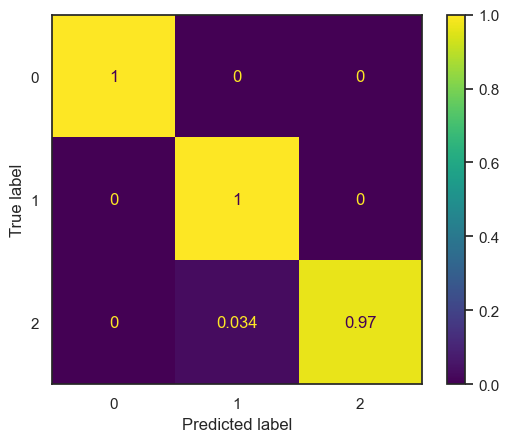

In [214]:
rf20 = RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 8, 
    random_state = 42)

rf20 = rf20.fit(data20_forest, y)

y_pred = rf20.predict(data20_forest)

cm = confusion_matrix(y, y_pred, normalize = 'true')

ConfusionMatrixDisplay(cm, display_labels=[0,1,2]).plot()

In [215]:
print(classification_report(y, y_pred, target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       0.99      1.00      0.99        96
           2       1.00      0.97      0.98        29

    accuracy                           0.99       186
   macro avg       1.00      0.99      0.99       186
weighted avg       0.99      0.99      0.99       186



In [216]:
result20['rf'] = rf20.predict(data20_forest)

result20['rf_hac_diff'] = abs(result20['rf'] - result20['hac18_3'])

In [217]:
rf_features = pd.Series(rf20.feature_importances_, index = df20_total.columns)
rf_features.sort_values(ascending = False)

infant_mort              0.161045
avg_infant_mort          0.147614
start_infant_mort        0.108728
elec                     0.107512
gdp                      0.072149
basic_water              0.062365
max_gdp_growth           0.060329
year_min_growth          0.047605
peak_health_exp          0.041719
min_gdp_growth           0.037327
pop                      0.034097
year_max_growth          0.030644
log_gdp_growth           0.028716
enroll_primary           0.025755
hac_cluster              0.021932
enroll_primary_growth    0.012463
dtype: float64

In [218]:
dtc20 = DecisionTreeClassifier(min_samples_leaf = 2,
    max_depth = 8, 
    random_state = 42)

dtc20.fit(data20_forest, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

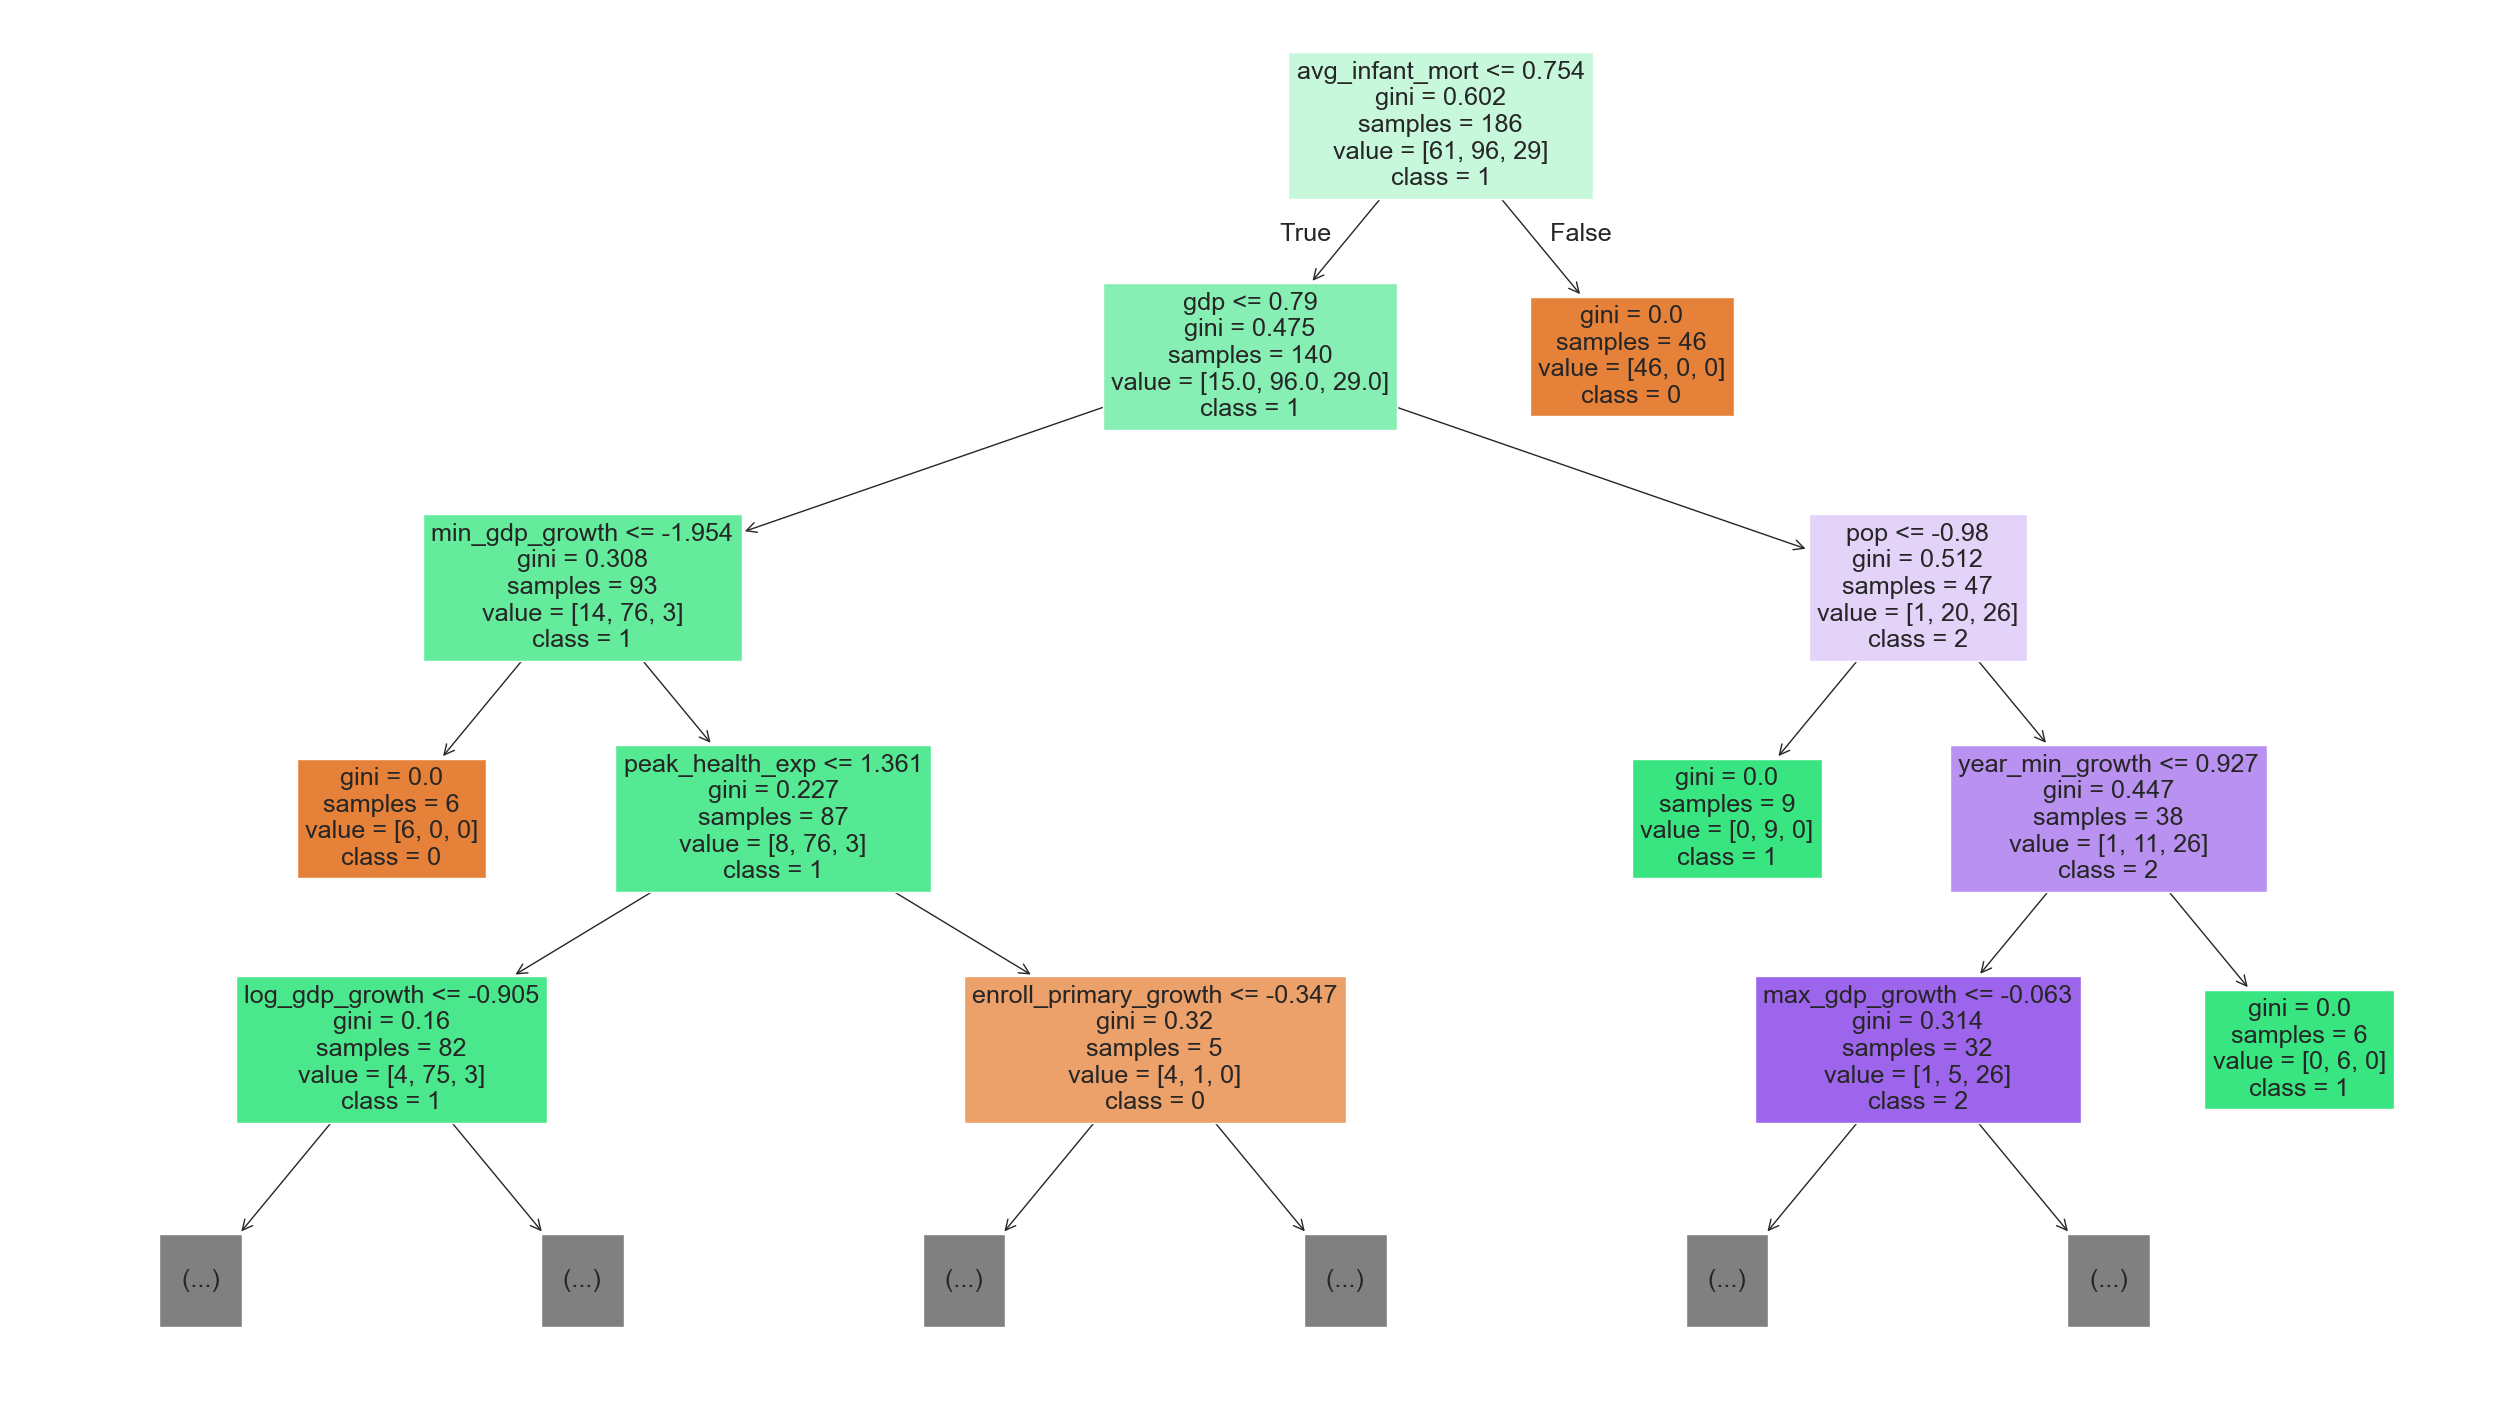

In [219]:
plt.figure(figsize = (32,18))
plot_tree(dtc20, feature_names = df20_total.columns, max_depth = 4, class_names = ['0', '1', '2'], filled = True)
#plt.savefig('tree.png', dpi = 150)
plt.show()

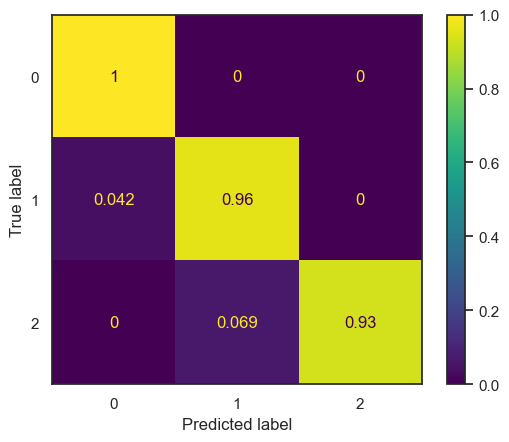

In [220]:
y_pred = dtc20.predict(data20_forest)

cm = confusion_matrix(y, y_pred, normalize = 'true')

ConfusionMatrixDisplay(cm, display_labels=[0,1,2]).plot()

In [221]:
print(classification_report(y, y_pred, target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        61
           1       0.98      0.96      0.97        96
           2       1.00      0.93      0.96        29

    accuracy                           0.97       186
   macro avg       0.97      0.96      0.97       186
weighted avg       0.97      0.97      0.97       186



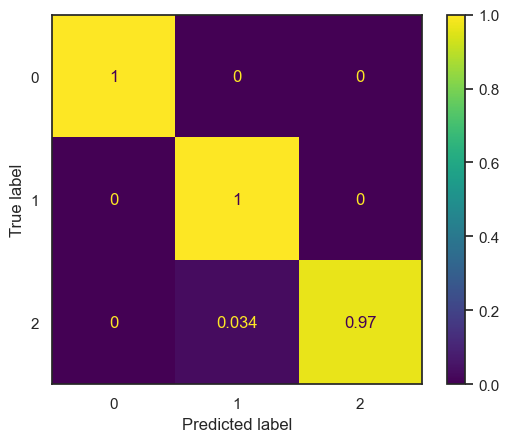

In [222]:
data20_forest_no_infmort = scaler.fit_transform(df20_total.reset_index().drop(
    columns = ['Country Code', 'avg_infant_mort', 'infant_mort', 'start_infant_mort']))

rf20_no_infmort = RandomForestClassifier(
    n_estimators = 200,
    min_samples_leaf = 2,
    max_depth = 8, 
    random_state = 42)

rf20_no_infmort = rf20_no_infmort.fit(data20_forest_no_infmort, y)

y_pred = rf20_no_infmort.predict(data20_forest_no_infmort)

cm = confusion_matrix(y, y_pred, normalize = 'true')

ConfusionMatrixDisplay(cm, display_labels=[0,1,2]).plot()

In [223]:
pd.Series(rf20_no_infmort.feature_importances_, index = df20_total.drop(columns = ['avg_infant_mort', 'infant_mort', 'start_infant_mort']).columns).sort_values(ascending = False)

gdp                      0.167465
basic_water              0.152837
elec                     0.147208
hac_cluster              0.094325
max_gdp_growth           0.078067
year_min_growth          0.062991
log_gdp_growth           0.055949
peak_health_exp          0.049483
pop                      0.043063
enroll_primary           0.040031
year_max_growth          0.039782
min_gdp_growth           0.037821
enroll_primary_growth    0.030977
dtype: float64

<Figure size 2000x2000 with 0 Axes>

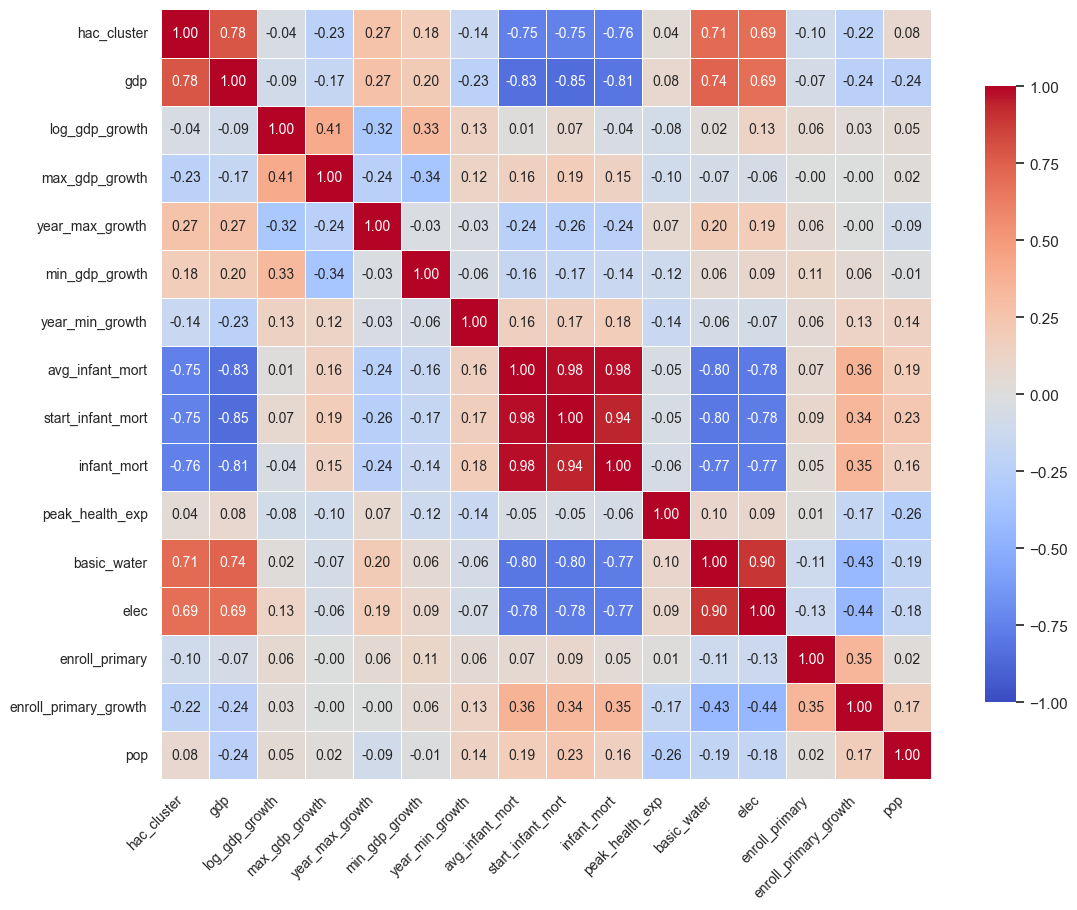

In [224]:
plt.figure(figsize = (20,20))
sns.set_theme(style="white", font_scale=1.0)  # font_scale controls global font size

# 3. Create figure and axis
plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    df20_total.corr(),
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 10, "fontweight": "normal"},  # numbers inside cells
    cbar_kws={"shrink": 0.8}
)

# 4. Adjust tick labels (axis labels for variables)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10,
    fontweight="normal"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
    fontweight="normal"
)
plt.show()

In [229]:
result20

,hac18,hac18_3,rf,rf_hac_diff
Country Code,,,,
AFG,12,0.0,0.0,0.0
AGO,8,0.0,0.0,0.0
ALB,6,1.0,1.0,0.0
AND,4,1.0,1.0,0.0
ARE,5,2.0,2.0,0.0
...,...,...,...,...
VNM,2,1.0,1.0,0.0
VUT,7,1.0,1.0,0.0
WSM,7,1.0,1.0,0.0


In [226]:
df_raw[df_raw['Country Code'] == 'YEM']

,Country Name,Country Code,Series Name,Series Code,2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
8153,"Yemen, Rep.",YEM,"PM2.5 air pollution, population exposed to lev...",EN.ATM.PM25.MC.ZS,100,..,..,..,..,100,...,100,100,100,..,..,..,..,..,..,..
8154,"Yemen, Rep.",YEM,"Population, female",SP.POP.TOTL.FE.IN,11273485,11639970,12016807,12402249,12797754,13198893,...,15350464,15821476,16308544,16805311,17319592,17830293,18330840,18866431,19440467,20025126
8155,"Yemen, Rep.",YEM,"Population, male",SP.POP.TOTL.MA.IN,11516600,11903113,12301275,12709692,13129970,13555494,...,15808915,16287534,16782377,17279871,17791816,18304570,18809390,19356445,19950332,20558038
8156,"Yemen, Rep.",YEM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,65.356,65.8,66.23,66.609,66.905,67.223,...,66.761,67.105,67.12,65.915,66.567,66.435,66.019,67.952,69.295,..
8157,"Yemen, Rep.",YEM,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,1.00446997706304,0.930975330843423,0.852591593321148,0.788529524726623,0.749920032061339,0.699964939447906,...,0.640829599907193,0.63676525552372,0.674144159387712,0.635209498189221,0.61888365140115,0.636757572265326,0.729314984505986,0.5816081037975,0.549043629658975,..
8158,"Yemen, Rep.",YEM,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,5.20585251,5.52930164,5.82077599,5.76191616,5.98619986,5.15932894,...,4.25285673,4.84506655,4.84769869,5.27201796,5.83812618,5.77270842,6.17542744,6.18666697,..,..
8159,"Yemen, Rep.",YEM,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,38.27000809,44.81512451,51.83703613,61.74676514,58.02085114,59.60072327,...,57.9312973,47.25681305,51.94430542,83.34048462,43.06481552,32.30203629,32.01807785,38.11569214,..,..
8160,"Yemen, Rep.",YEM,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,0.61,0.66,0.64,0.63,0.65,0.65,...,0.71,0.71,0.71,..,..,..,..,..,..,..
8161,"Yemen, Rep.",YEM,"Mortality rate, infant, female (per 1,000 live...",SP.DYN.IMRT.FE.IN,53.9,51.1,48.4,46.1,44,42.2,...,37.5,36.6,35.9,35.8,35.1,33.7,33.1,32.1,31.1,..
8162,"Yemen, Rep.",YEM,"Mortality rate, infant, male (per 1,000 live b...",SP.DYN.IMRT.MA.IN,63.3,60.3,57.5,54.9,52.7,50.7,...,45.1,44.2,43.3,43.1,42.3,40.9,40.2,39.1,38,..
